In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
#Load Dataset
df = sns.load_dataset("mpg")

In [22]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [7]:
df = df.dropna()

# Define features and target
X = df[['displacement']]
y = df['mpg']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

lin_mse = mean_squared_error(y_test, y_pred_linear)
lin_r2 = r2_score(y_test, y_pred_linear)

In [11]:
#Polynomial Regression
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

In [23]:
#Display Comparision

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression (Deg 1)", f"Polynomial Regression (Deg {degree})"],
    "MSE": [lin_mse, poly_mse],
    "R² Score": [lin_r2, poly_r2]
})

In [24]:
print("Performance Comparison")
print(comparison_df.to_string(index=False))

Performance Comparison
                        Model       MSE  R² Score
    Linear Regression (Deg 1) 21.227484  0.584106
Polynomial Regression (Deg 3) 20.817941  0.592130


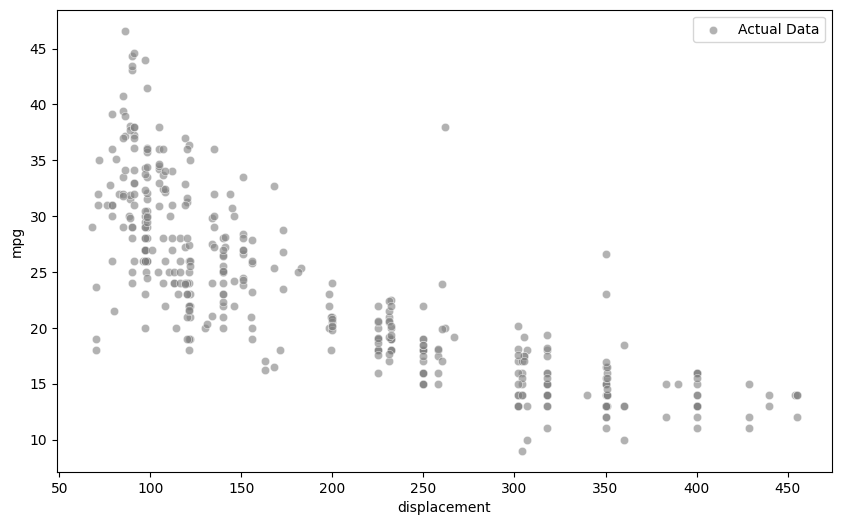

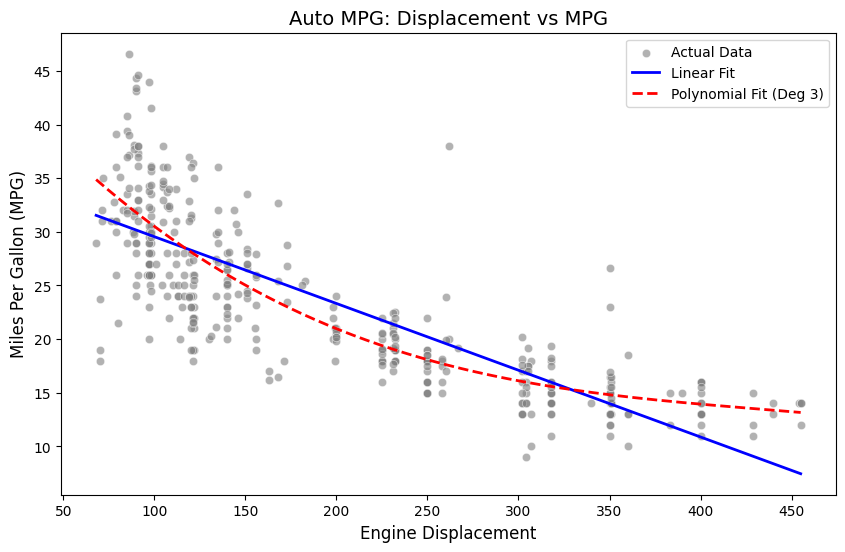

In [37]:
plt.figure(figsize=(10, 6))
#plot of actual data with Seaborn
sns.scatterplot(data=df, x='displacement', y='mpg', color='gray', alpha=0.6, label='Actual Data')
X_range = pd.DataFrame(np.linspace(X.min(), X.max(), 500), columns=['displacement'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='displacement', y='mpg', color='gray', alpha=0.6, label='Actual Data')

plt.plot(X_range, linear_model.predict(X_range), color='blue', linewidth=2, label='Linear Fit')

X_range_poly = poly_features.transform(X_range)
plt.plot(X_range, poly_model.predict(X_range_poly), color='red', linestyle='--', linewidth=2, label=f'Polynomial Fit (Deg {degree})')

plt.title('Auto MPG: Displacement vs MPG', fontsize=14)
plt.xlabel('Engine Displacement', fontsize=12)
plt.ylabel('Miles Per Gallon (MPG)', fontsize=12)
plt.legend()
plt.show()


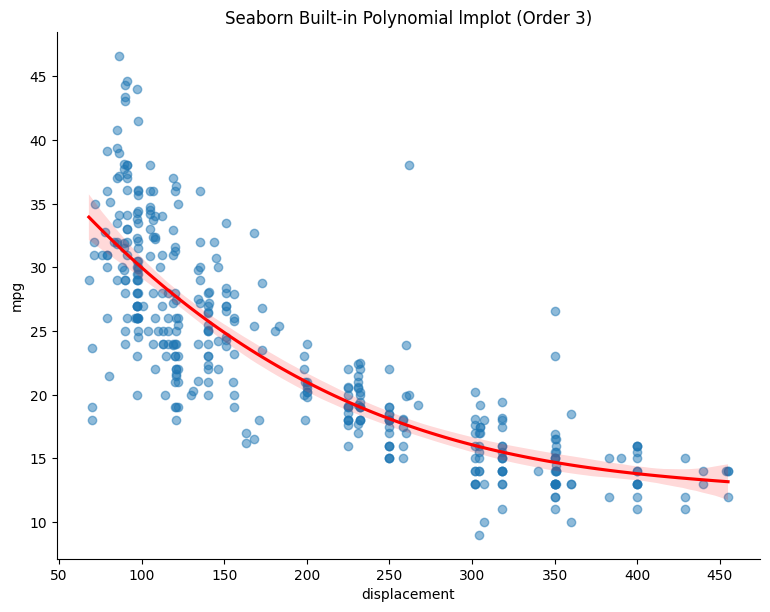

In [26]:
sns.lmplot(data=df, x='displacement', y='mpg', order=3, height=6, aspect=1.3, 
           scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Seaborn Built-in Polynomial lmplot (Order 3)')
plt.show()